# Plots & Graphs

Time to unleash the right side of your brain!

Truthfuly, we should have been working with plots for the last few sections way more extensively than we have.  Instead of introducing too many topics at once, we intentionally paused delving into the the visual exploration side of things so we could focus on one thing at a time.  Now that the analytical side of Exploratory Data Analysis (EDA) is behind us, it's time to see how adding some visual creativity to your arsenal will pay huge dividends!

```{figure} ../images/right_brain.png
---
width: 600px
name: right-brain-fig
---
```

Plots and graphs will come into play in multiple stages during the course of your project.  For now, they'll help in your EDA work with basic understandings of what you're working with, investigating raw features, and helping to identify if there are any potential issues in the data.  Then once you start moving into feature engineering and transformations you'll begin visualizing your updates and relational effects between your variables.  Finally, when you start getting into building models and iterating through versions, you'll need some way to visualize the progress, tuning, and performance of your candidate models.

At our current stage, all of the visuals and graphics you'll be building are purely for your benefit.  They can be as simple and utilitarian, or as pretty as you want them to be.  The main focus during this early investigatory phase is to advance your understanding of the data under study.

Let's begin with talking about the various types of plots you should know about and feel comfortable with the situational usages for each.

**<h3>Types of Plots</h3>**

First off, you'll often see the words "plots" and "graphs" used interchangeably, but usually intended to mean the same thing.  These are simply visual graphics of some kind.  Plots more commonly refer to the techinical side of what we're doing in our application environments, and serve as a catch-all to encompass all kinds of visuals, from proper graphs to images.  Graphs will mostly be referencing the visualization of numeric or categorical data in some way.

Borrowing, and gently updating {numref}`plot-types-fig` below from the <a href="https://seaborn.pydata.org/tutorial.html">Seaborn User Guide and Tutorial</a>, is about as straight forward as I've ever seen an illustration laying out the most common graphs and their uses.  There are of course others and more exotic plot types for specific purposes, such as heatmaps, area, autocorrelation, 3D, graph networks, images, word clouds, animated/interactive, and so on, but what we'll reveiw will cover the overwhelming majority of our needs for now.

```{figure} ../images/plot_types.png
---
width: 500px
name: plot-types-fig
---
Source: https://seaborn.pydata.org/tutorial/function_overview.html
```

For each pillar of plot types, we'll discuss in more detail when we get to each section, but for now hopefully you can see there are really only a few different reasons you might want to display data graphically, i.e. for Relational, Distributions, and Categorical data.  That's pretty much it for the most part.

You either want to compare some values or sequence of values __(relational)__, investigate the dispersion of a data sample under study __(distributions)__, or you want to visualize the frequencies or proportionality of __categorical__ (non numeric) data in some way.  

All of the plot types under each pillar simply give you options and flexibility to tailer your view to the specifics of your actual data.  Honestly, you could probably learn three or four different types of graphs and be all set for 95% of the analytics we need to perform.  Of course we love having the flexibility and options to really dial in our graphics, but you could get by nonetheless.

We'll use {numref}`plot-types-fig` as the reference to motivate our examples below.

A couple of final thoughts before jumping in.

1. Start with thinking about your data before thinking about the types of plots
   - What type of data do I have?  e.g. cross sectional, time series
   - What's the unit of analysis?
   - What are the values (the features and data points you want to see in the plot) in your data?
   - Are there any categorical features you may want to condition on or separate (group/compare/facet) your values with?
2. Simple is always better
   - Going overboard and adding too many dimensions (values, groupings, color, size, shapes, etc.) in your plots is generally a bad idea
   - Complicated visuals will overwhelm and confuse most audiences
3. Exploratory graphics do not have to be pretty
   - EDA plots are for you, and only need to be what you need them to be to get value out of
   - Presentation graphics are for others, and need to be simple, clear, and informative

Enough words.  Let's see some examples!

**<h3>Relational Plots</h3>**

These are probably the most common types of graphs we work with.  _Relational_ means you have some variable(s) of interest you'd like to compare with other features or across time.  Sounds complicated, but it's really pretty straightforward.

We'll again use the "tips" dataset to work through our examples below.  This popular dataset holds the record of tips received by a waiter over the course of several months.  Features present are the tip amount, bill total, sex/gender of the payer, if any smokers were present in the party, the day of the week, the time of day, and the size of the party.

Let's take a look.

In [13]:
import seaborn as sns

dat = sns.load_dataset("tips") 
dat.reset_index(drop = True, inplace = True)
dat[17:22].style.format({'total_bill':'${:,.2f}',
                   'tip':'${:,.2f}'})

,total_bill,tip,sex,smoker,day,time,size
17,$16.29,$3.71,Male,No,Sun,Dinner,3
18,$16.97,$3.50,Female,No,Sun,Dinner,3
19,$20.65,$3.35,Male,No,Sat,Dinner,3
20,$17.92,$4.08,Male,No,Sat,Dinner,2
21,$20.29,$2.75,Female,No,Sat,Dinner,2


So what can we say about this data set?

_What kind of data is it?_  **Panel** <br>
_What's the unit of analysis?_  **Total bill and tip amounts, by guest party (size, sex, smoker), by day (day, time)** <br>
_What are the values?_  **Total bill & tip $ amounts** <br>
_What are the categorical (conditioning) variables?_  **sex, smoker, day, time, size**

<h4>Scatter Plots</h4>

Scatter plots are excellent places to get started because they're pretty simple, and usually only a couple of variables.  While these types of plots could be used with categorical data such as `day` on the x axis, it makes much more sense to view the relationships between numeric features.  Here we have three continuous variables in `total_bill`, `tip`, and `size`.

You'll come to start thinking about your data in terms of primary and secondary, and/or aesthetic variables, meaning information you could use to segment or further subclassify your data to give further contextual information.

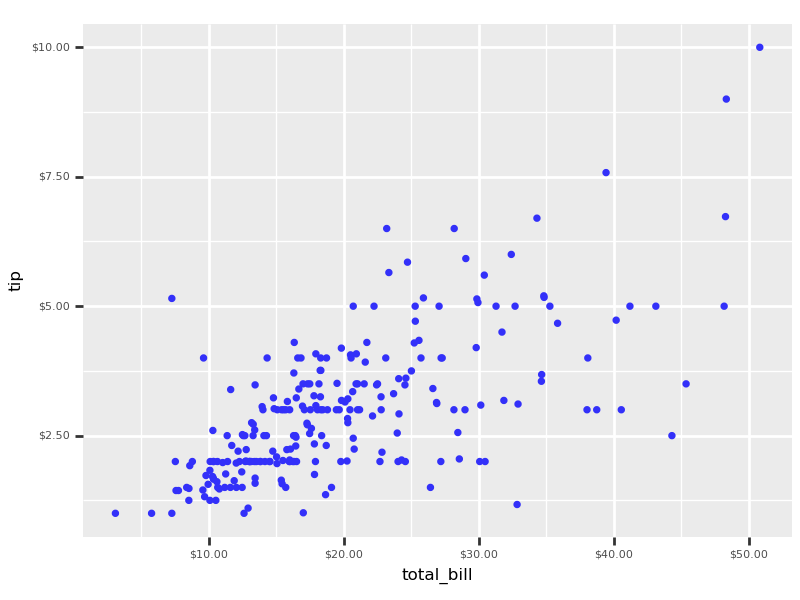

In [17]:
# Load library
import warnings
from plotnine import *
from mizani.formatters import currency_format, comma_format, percent_format
import warnings
from IPython.display import Markdown as md
warnings.filterwarnings('ignore')

# Plot scatterplot
p = (ggplot(dat, aes(x = 'total_bill', y = 'tip')) + 
         geom_point(color = "#3330f9", size = .5) +
         theme(plot_title = element_text(size = 8),
               axis_text_x = element_text(size = 4),
               axis_text_y = element_text(size = 4),
               axis_title = element_text(size = 6),
               legend_title = element_text(size = 6),
               legend_text = element_text(size = 4),
               strip_text = element_text(size = 6),
               figure_size = (4,3)) +
          scale_y_continuous(labels = currency_format("$", digits = 2)) +
          scale_x_continuous(labels = currency_format("$", digits = 2)))

p.draw(show = False)

Cool.  Our first exploratory plot!  We're _relating_ the size of each individual `tip` amount to the overall size of their `total bill`.  So what can we see?  Maybe you noticed a nice linear trend as the total bill gets larger, generally so does the size of the tip?  Maybe you noticed a few points that do _not_ follow those same general patterns?  Like the anomaly of someone tipping over \$5 on a \$7 bill?

Good start, but what else could we do here?  Maybe you thought about adding an additional segmentation _aesthetic_ using color in some way?  How about if we highlight each point by `sex`(male or female)?

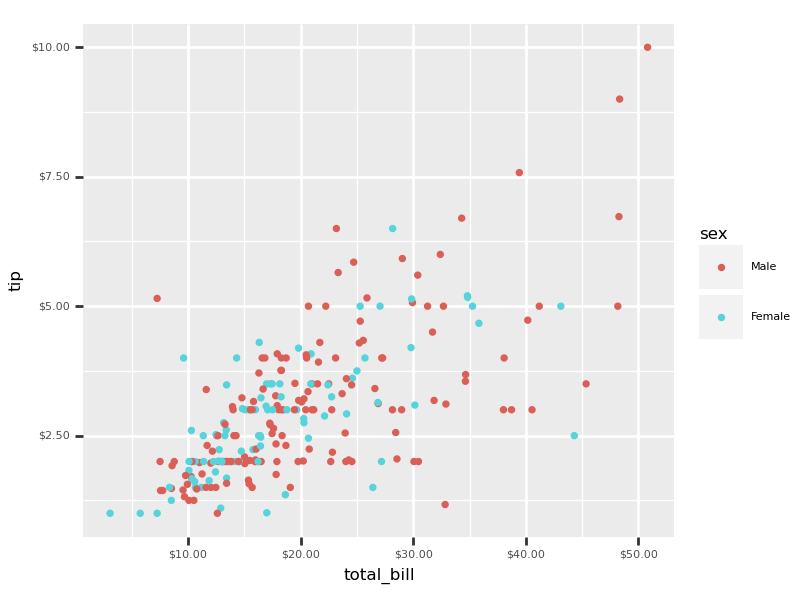

In [19]:
# Plot simple scatterplot with gender color aesthetic
p = (ggplot(dat, aes(x = 'total_bill', y = 'tip', color = 'sex')) +
         geom_point(size = .5) +
         theme(plot_title = element_text(size = 8),
               axis_text_x = element_text(size = 4),
               axis_text_y = element_text(size = 4),
               axis_title = element_text(size = 6),
               legend_title = element_text(size = 6),
               legend_text = element_text(size = 4),
               strip_text = element_text(size = 6),
               figure_size = (4,3)) +
          scale_y_continuous(labels = currency_format("$", digits = 2)) +
          scale_x_continuous(labels = currency_format("$", digits = 2)))

p.draw(show = False)

Hmm... unfortunately looks like pretty uniform dispersion so it doesn't appear to be too informational.  What if we add linear fit trendlines for each gender?

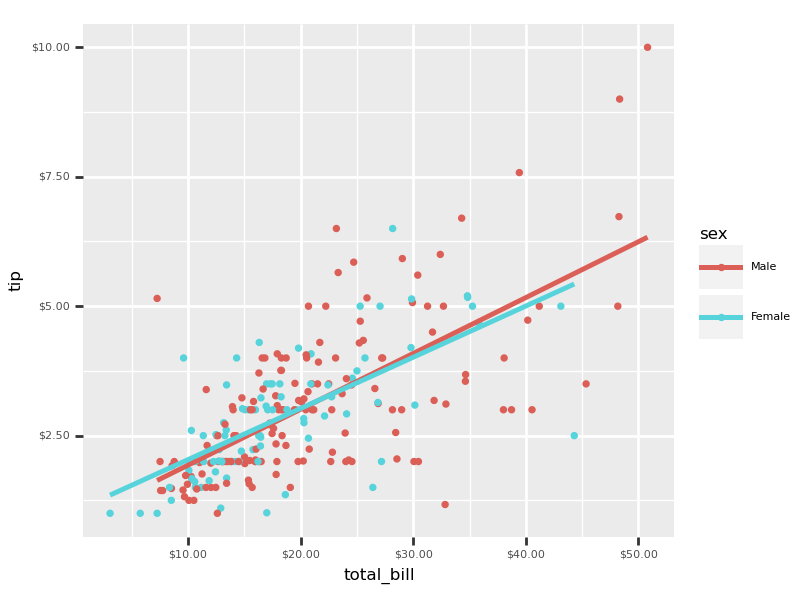

In [21]:
# Plot with lm fit
p = (ggplot(dat, aes(x = 'total_bill', y = 'tip', color = 'sex')) +
         geom_point(size = .5) +
         geom_smooth(method = "lm", se = False) +  
         theme(plot_title = element_text(size = 8),
               axis_text_x = element_text(size = 4),
               axis_text_y = element_text(size = 4),
               axis_title = element_text(size = 6),
               legend_title = element_text(size = 6),
               legend_text = element_text(size = 4),
               strip_text = element_text(size = 6),
               figure_size = (4,3)) +
          scale_y_continuous(labels = currency_format("$", digits = 2)) +
          scale_x_continuous(labels = currency_format("$", digits = 2)))

p.draw(show = False)

As we first suspected.  Not much difference based on the sexes; however, the up sloping trendlines do confirm what we first observed in a general up trend of tipping more as the total bill increases.

Let's move on to segment, or facet, by whether or not each group was a `smoker` group or not, and also we'll use a coloring aesthetic to highlight the size of each group.

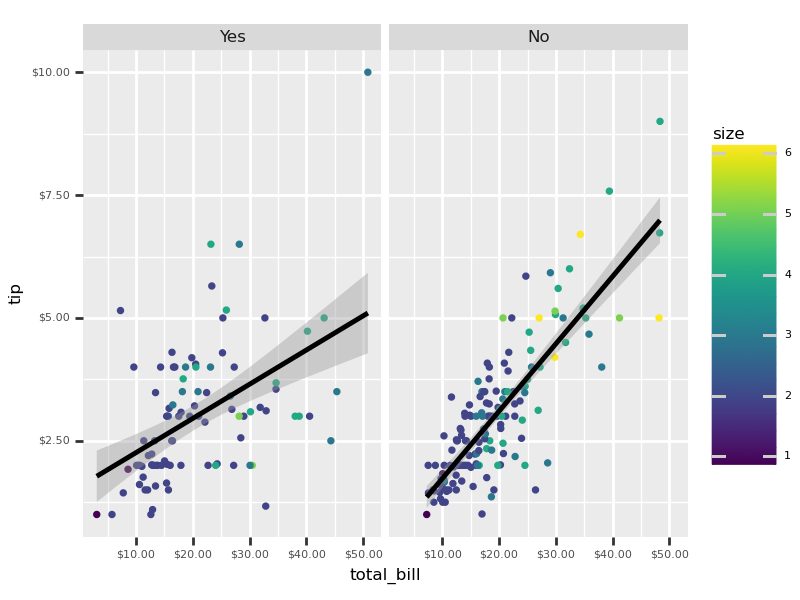

In [23]:
# Plot with lm fit and standard errors
p = (ggplot(dat, aes(x = 'total_bill', y = 'tip', color = 'size')) +
         geom_point(size = .5) +
         geom_smooth(method = "lm") +  
         theme(plot_title = element_text(size = 8),
               axis_text_x = element_text(size = 4),
               axis_text_y = element_text(size = 4),
               axis_title = element_text(size = 6),
               legend_title = element_text(size = 6),
               legend_text = element_text(size = 4),
               strip_text = element_text(size = 6),
               figure_size = (4,3)) +
          scale_y_continuous(labels = currency_format("$", digits = 2)) +
          scale_x_continuous(labels = currency_format("$", digits = 2)) +
          facet_wrap('smoker'))

p.draw(show = False)

Anything jump out at you?  Maybe the differences in the slopes (angles) of the regression lines?  Or the wider confidence intervals (widths) at the extreme values for the `smoker = Yes` group? There's a ton of information in this one, but I'll leave it to you to pick it apart further.

Although we could, we don't want to spend all day on scatterplots.  We need to move on to some other types.  

Next up, line plots.

<h4>Line Plots</h4>

Line plots are pretty straightforward.  These are the stuff of _time series_ data that we discussed in our {doc}`data_types` section.  It doesn't really make sense to connect data point by point if they're independent observations that have no dependency across time.  Let's see what we're talking about by reading in a dataset from the St. Louis Federal Reserve {cite}`FRED_2024` with the following features:

- DATE - Month
- CPI - Consumer Price Index
- PCE - Personal Consumption Expendature
- AHW - Average Hourly Wage
- CSI - Consumer Sentiment Index

Recall from our discussion about time series data types, what you should notice straight away is that this data carries a _time_ component.  This is what allows you to connect the points in time over the x-axis.

In [27]:
import pandas as pd

# Read in FRED data from Github
url = 'https://github.com/bradybr/practical-data-science-and-ml/blob/main/datasets/FRED.csv?raw=true'
dat = pd.read_csv(url, sep = ",")
dat.head(5)

,DATE,CPI,PCE,AHW,CSI
0,1/1/2007,85.832240,9538.7,20.59,96.9
1,2/1/2007,86.165127,9566.0,20.68,91.3
2,3/1/2007,86.613197,9611.7,20.73,88.4
3,4/1/2007,86.873093,9643.6,20.78,87.1
4,5/1/2007,87.232139,9685.8,20.84,88.3


In [28]:
# Update DATE to datetime
dat['DATE'] = pd.to_datetime(dat['DATE'])

# Print statistical summaries
dat.describe().T

,count,mean,min,25%,50%,75%,max,std
DATE,204,2015-06-16 19:31:45.882352896,2007-01-01 00:00:00,2011-03-24 06:00:00,2015-06-16 00:00:00,2019-09-08 12:00:00,2023-12-01 00:00:00,NaN
CPI,204.0,102.634476,85.83224,94.436791,100.202939,108.037504,130.307109,11.143778
PCE,204.0,12820.531373,9538.7,10644.0,12291.65,14299.025,19001.7,2616.071004
AHW,204.0,25.885931,20.59,22.9,24.985,28.1875,34.27,3.694348
CSI,203.0,79.699015,50.0,69.85,79.0,91.8,101.4,13.309146


We can see that some of these variables are indexes, and others are one very different range scales, so let's start with just one series before getting too complicated.

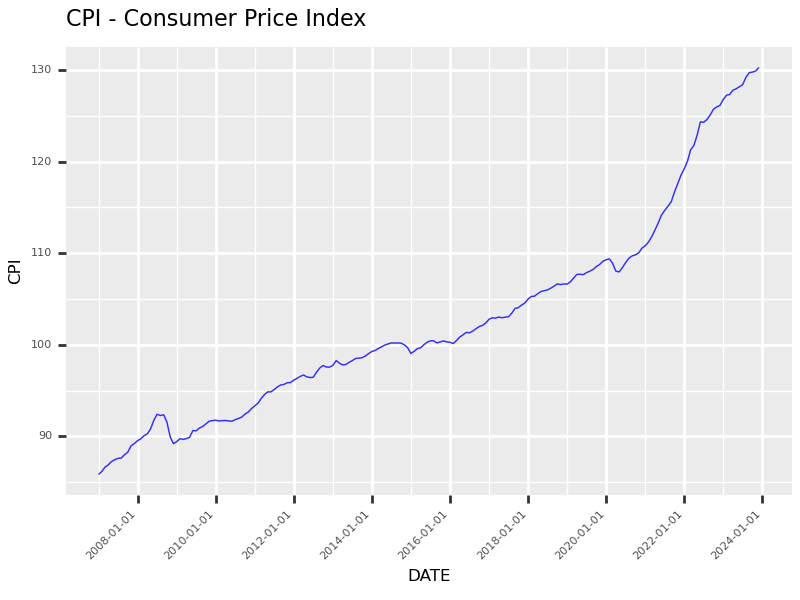

In [30]:
# CPI Time Series line plot
p = (ggplot(dat, aes(x = 'DATE', y = 'CPI')) +
         geom_line(color = "#3330f9", size = .3) + 
         ggtitle("CPI - Consumer Price Index") +  
         theme(axis_text_x = element_text(rotation = 45, hjust = 1, size = 4),
               plot_title = element_text(size = 8),
               axis_text_y = element_text(size = 4),
               axis_title = element_text(size = 6),
               legend_title = element_text(size = 6),
               legend_text = element_text(size = 4),
               strip_text = element_text(size = 6),
               figure_size = (4,3)))

p.draw(show = False)

Now what if we wanted to plot all 4 of the series together?  Could we do that?  Yes we could, but unfortunately you wouldn't be able to read them due to the issue of them all being on different scales.  We would have to normalize or standardize each individual series to be on the same scale first.  Otherwise, the large values of the PCE series would overwhelm the smaller ones and you would not be able to see any variance.

Another way we can get them all on one plot _without_ adjusting the values is called faceting.  Faceting essentially breaks out each series into its own subplot and allows each to have independent y-axis ranges instead of sharing.

See below.

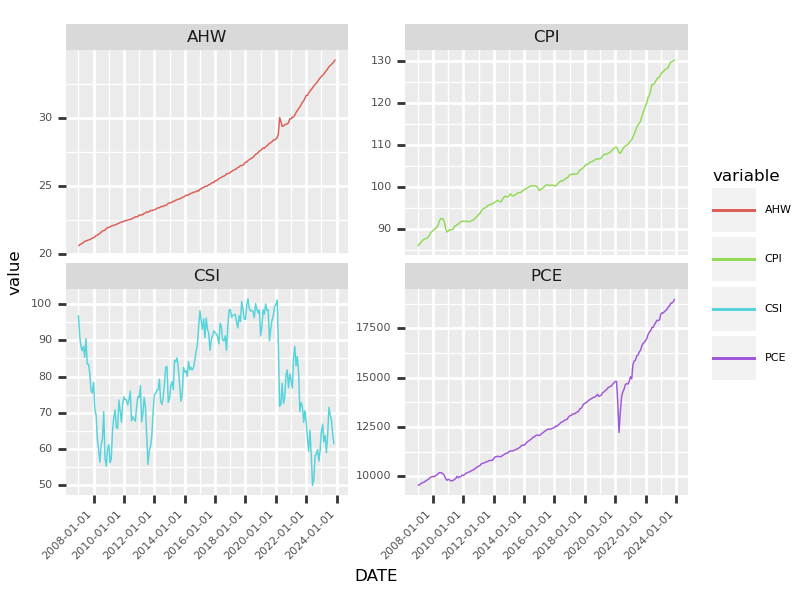

In [32]:
# Melt data from wide to long
melted_dat = pd.melt(dat, id_vars = 'DATE')

# Facet Plot
p = (ggplot(melted_dat, aes(y = 'value', x = 'DATE', color = 'variable')) +
         geom_line(size = .3) +
         theme(axis_text_x = element_text(rotation = 45, hjust = 1, size = 4),
               plot_title = element_text(size = 8),
               axis_text_y = element_text(size = 4),
               axis_title = element_text(size = 6),
               legend_title = element_text(size = 6),
               legend_text = element_text(size = 4),
               strip_text = element_text(size = 6),
               figure_size = (4,3)) +
         facet_wrap('variable', scales = 'free_y'))

p.draw(show = False)

One more for good measure.  Let's see how we'd normalize each series so we could get them all on one graph instead of the subplots, in case that's what you're after.

There are several ways we could do this, but we're going to keep it simple and create a normalized index out of each variable.  Notice the scale and shapes remain the same, but we no longer can see the original values.  We'll talk more about this soon when we get to transformations in the Feature Engineering section.

In [34]:
# Set the variables to normalize
vars = ['CPI','PCE','AHW','CSI']

# Normalize by dividing by the first value of each series
dat[vars] = dat[vars].div(dat[vars].iloc[0])

# Melt data from wide to long
melted_dat = pd.melt(dat, id_vars = 'DATE')

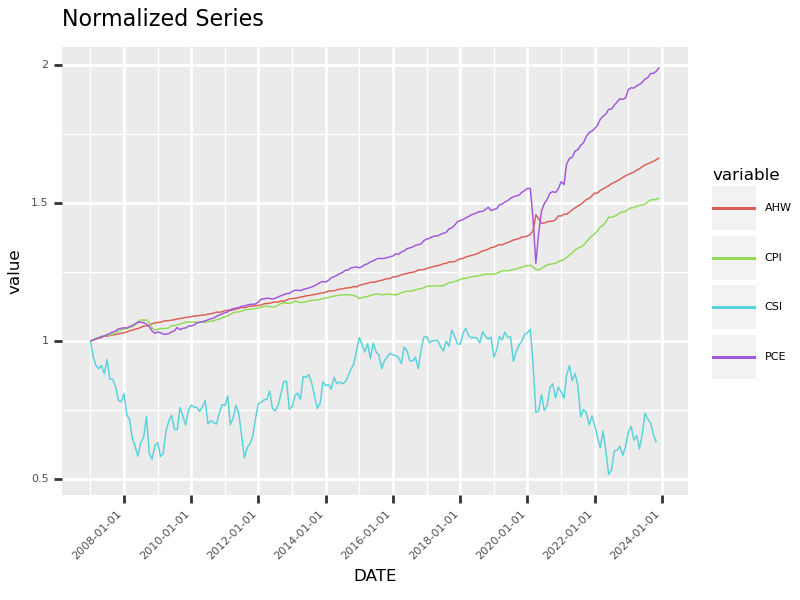

In [35]:
# Normalized Series Plot
p = (ggplot(melted_dat, aes(y = 'value', x = 'DATE', color = 'variable')) +
         geom_line(size = .3) +
         ggtitle("Normalized Series") +  
         theme(axis_text_x = element_text(rotation = 45, hjust = 1, size = 4),
               plot_title = element_text(size = 8),
               axis_text_y = element_text(size = 4),
               axis_title = element_text(size = 6),
               legend_title = element_text(size = 6),
               legend_text = element_text(size = 4),
               strip_text = element_text(size = 6),
               figure_size = (4,3)))

p.draw(show = False)

**<h3>Distributional Plots</h3>**

Plots that show the statistical moments of the data in a distribution, or spread, of the data can be extremely helpful in understanding the behavior of our sample under study.  We'll start with the most common and cover a few lesser used as well.

Continuing with the tips dataset.


In [38]:
# Re-read in the tips data & create tip % variable again
dat = sns.load_dataset("tips") 
dat.reset_index(drop = True, inplace = True)
dat['tip_pct'] = dat.tip / dat.total_bill

dat[17:22].style.format({'total_bill':'${:,.2f}',
                         'tip':'${:,.2f}'})

,total_bill,tip,sex,smoker,day,time,size,tip_pct
17,$16.29,$3.71,Male,No,Sun,Dinner,3,0.227747
18,$16.97,$3.50,Female,No,Sun,Dinner,3,0.206246
19,$20.65,$3.35,Male,No,Sat,Dinner,3,0.162228
20,$17.92,$4.08,Male,No,Sat,Dinner,2,0.227679
21,$20.29,$2.75,Female,No,Sat,Dinner,2,0.135535


<h4>Histograms</h4>

Histograms are probably the most familiar, and the most common to visualize the frequency counts of data series.  These graphs show the frequency of numerical data in the form of vertical rectangles illustrating how many times that value range was observed in the data (higher = more frequent).

Let's see what the range of values looks like in our `total_bill` variable.

In [41]:
# Print summary statistics
dat[['total_bill']].describe().T

,count,mean,std,min,25%,50%,75%,max
total_bill,244.0,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81


We can see that the average value is around \$20 dollars, with the inner quartile range of \$13-24.  Now let's see what this looks like plotted in a historgram.

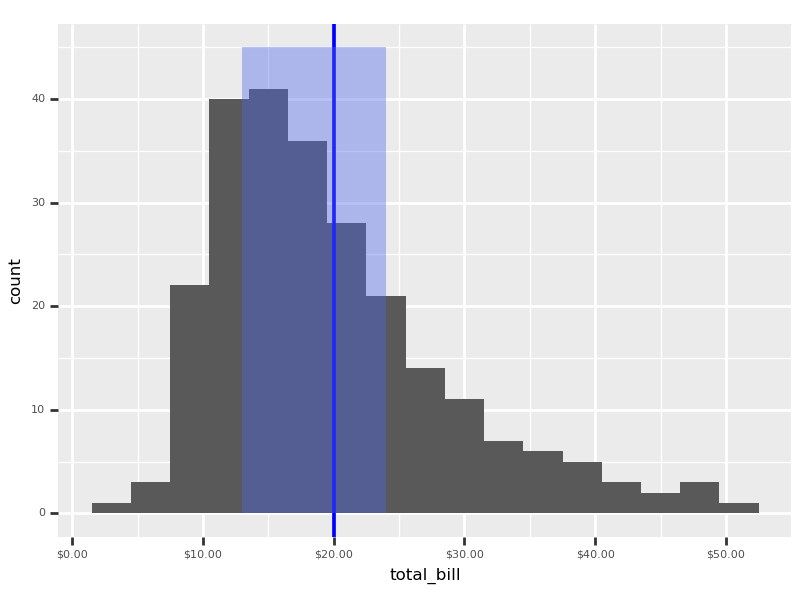

In [43]:
# Plot histogram
p = (ggplot(dat, aes('total_bill')) +
         geom_histogram(binwidth = 3) +
         geom_vline(xintercept = 20, color = "blue", size = .75) + 
         annotate("rect", xmin = 13, xmax = 24, ymin = 0, ymax = 45, alpha = 0.4, fill = "#4E68EC") +
         theme(axis_text_x = element_text(size = 4),
               plot_title = element_text(size = 8),
               axis_text_y = element_text(size = 4),
               axis_title = element_text(size = 6),
               legend_title = element_text(size = 6),
               legend_text = element_text(size = 4),
               strip_text = element_text(size = 6),
               figure_size = (4,3)) +
          scale_x_continuous(labels = currency_format("$", digits = 2)))

p.draw(show = False)

Nice!  That's pretty much exactly what we see.  Our data is right (positive) skewed, shown in that sweeping tail out to the right of our histogram.  It's a little hard to see the nuances of the full distribution though because of the "coarseness".  This is due to the number of chosen bins in the plotting function.  

Histograms have a parameter called "bins" that you can adjust to increase or decrease the width of the discrete ranges on the x-axis.  Let's try making it a little more spread out by adjusting the "binwidth" parameter.

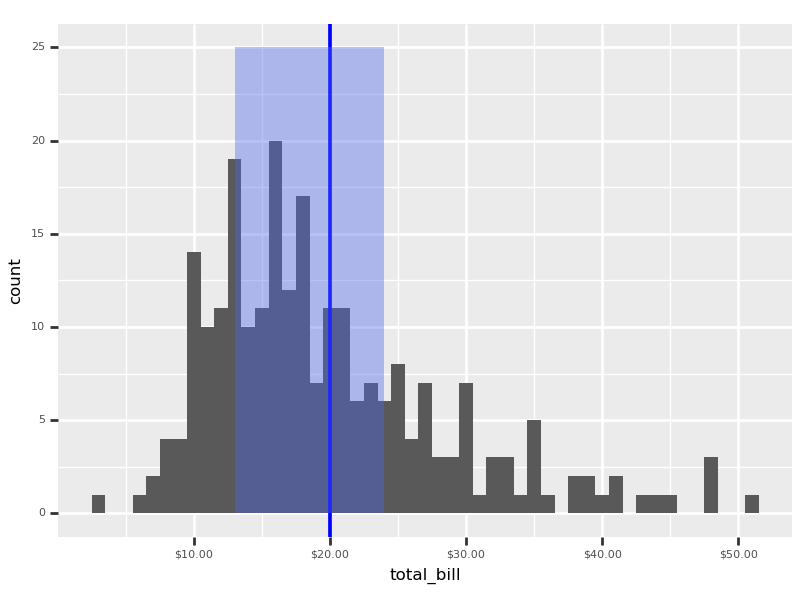

In [45]:
# Plot historgram with more granular "binwidth"
p = (ggplot(dat, aes('total_bill')) +
         geom_histogram(binwidth = 1) +
         geom_vline(xintercept = 20, color = "blue", size = .75) + 
         annotate("rect", xmin = 13, xmax = 24, ymin = 0, ymax = 25, alpha = 0.4, fill = "#4E68EC") +
         theme(axis_text_x = element_text(size = 4),
               plot_title = element_text(size = 8),
               axis_text_y = element_text(size = 4),
               axis_title = element_text(size = 6),
               legend_title = element_text(size = 6),
               legend_text = element_text(size = 4),
               strip_text = element_text(size = 6),
               figure_size = (4,3)) +
          scale_x_continuous(labels = currency_format("$", digits = 2)))

p.draw(show = False)

Interesting.  See how we lost all of the aggregated groupings?  Historgrams are particular in the number of bins required to really see what's going on.  When you start wanting to see this kind of granularity, maybe you want the next kind of plot we'll look at called density plots.

<h4>Density Plots</h4>

If the aggregated coarseness of the historgram was too much for you, maybe you're looking for a smoothed version that will nicely show the overall distribution of data.  Enter the density plot.  Here we lose the frequency counts in favor of the probability density function of a variable.  Sounds complicated, however the same idea applies as with the histogram where the larger more peaked areas occur more frequently.  Simple as that.

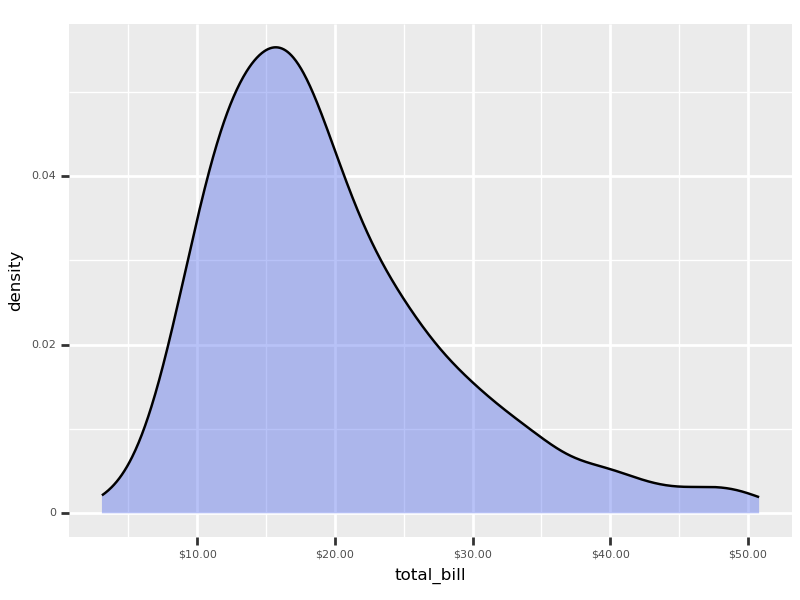

In [49]:
# Density plot
p = (ggplot(dat) +
         geom_density(aes('total_bill'), fill = "#4E68EC", alpha = .4) +
         theme(axis_text_x = element_text(size = 4),
               plot_title = element_text(size = 8),
               axis_text_y = element_text(size = 4),
               axis_title = element_text(size = 6),
               legend_title = element_text(size = 6),
               legend_text = element_text(size = 4),
               strip_text = element_text(size = 6),
               figure_size = (4,3)) +
          scale_x_continuous(labels = currency_format("$", digits = 2)))

p.draw(show = False)

Let's overlay our density curve on top of our histogram and see how they compliment each other.

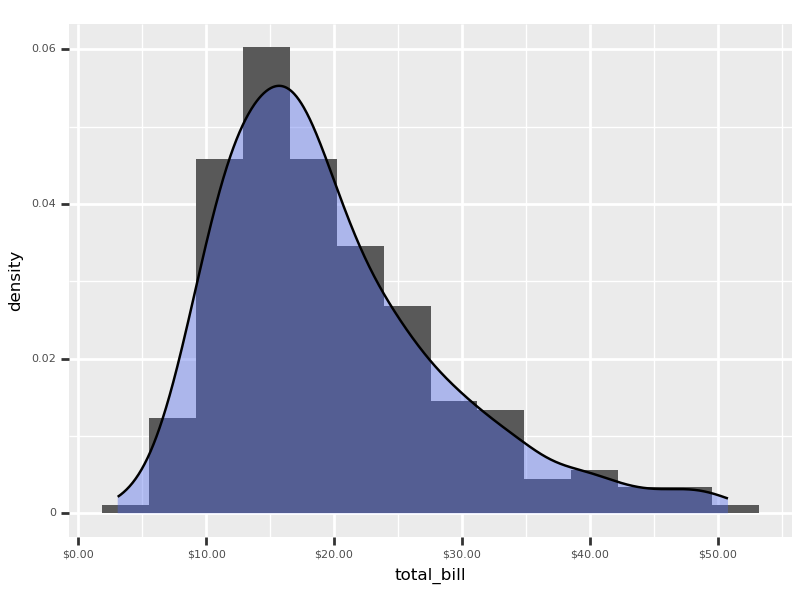

In [51]:
# Plot density curve over the histogram
p = (ggplot(dat, aes(x = "total_bill", y = after_stat("density"))) +
         geom_histogram() +
         geom_density(fill = "#4E68EC", alpha = .4) +
         scale_fill_discrete(guide = False) +
         theme(axis_text_x = element_text(size = 4),
               plot_title = element_text(size = 8),
               axis_text_y = element_text(size = 4),
               axis_title = element_text(size = 6),
               legend_title = element_text(size = 6),
               legend_text = element_text(size = 4),
               strip_text = element_text(size = 6),
               figure_size = (4,3)) +
          scale_x_continuous(labels = currency_format("$", digits = 2)))

p.draw(show = False)

Very nice.  We can see the obvious differences between the two representations, but also where they share the same distributional shape.  Sometimes you don't need or want to see the frequency steps and jagged jumps, and would prefer to see the smooth curve.

Now, let's take one last look by visualizing `tip` and `total bill` amounts on the same graph overlaying their individual density curves.  

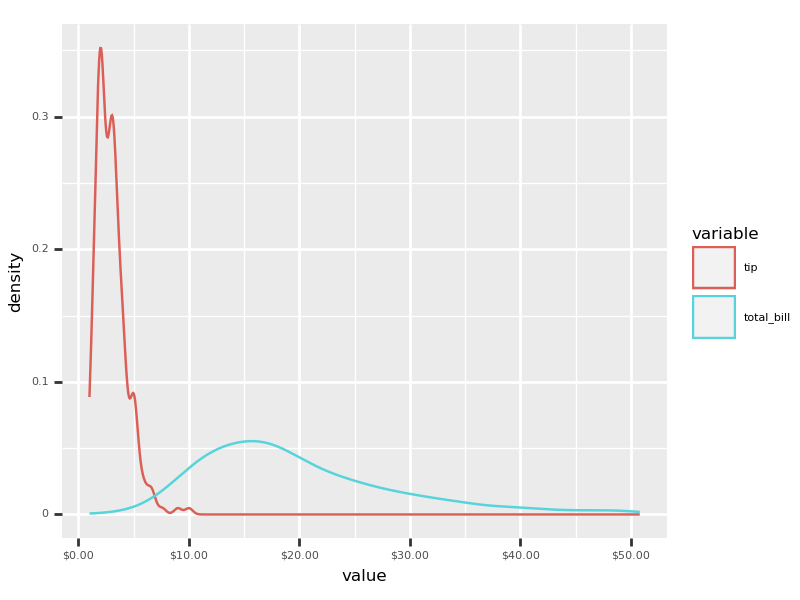

In [53]:
import pandas as pd

# Melt dataset from wide to long
melted_dat = pd.melt(dat, id_vars = ['sex','smoker','day','time'])

# Plot multiple density plots
p = (ggplot(melted_dat[~melted_dat.variable.isin(['tip_pct','size'])], aes(x = 'value', color = 'variable')) +
         geom_density() +
         theme(axis_text_x = element_text(size = 4),
               plot_title = element_text(size = 8),
               axis_text_y = element_text(size = 4),
               axis_title = element_text(size = 6),
               legend_title = element_text(size = 6),
               legend_text = element_text(size = 4),
               strip_text = element_text(size = 6),
               figure_size = (4,3)) +
          scale_x_continuous(labels = currency_format("$", digits = 2)))

p.draw(show = False)

<h4>ECDF (Empirical Cumulative Density Function)</h4>

Now for the final distributional type of graph we'll cover:  Empirical Cumulative Density Functions (ECDF)

This type of plot calculates the fraction of observations that are less than or equal to a specific point in the distribution of the sample.  Probability density curves are extremely beneficial when you need to model or simulate from an observed sample (empirical) because a theoretical distribution will not fit or work.

Sounds complicated, I know.  It's really pretty simple though.  Let's illustrate by simulating a coin flipping game that either _wins_ 1 token or _loses_ 1 token with each flip.

We'll simulate playing this game **100** times.  Each game starts out with **10** tokens, and will consist of flipping a coin up to **1,000** times.  Each game will terminate either by running out of tokens when the player hits zero, or by hitting the maximum number of flips set to 1,000.  

Still sound complicated?  Let's run the simulation and take a look below at the first 10 games and see if it helps make it more clear.

In [56]:
import numpy as np

# Game function that wins +1 or costs us -1 token with each flip of a coin
def play_fun(start_amt = 10, n_flips = 1000, win_prob = .5):
    flips = np.random.choice([1,-1], size = n_flips, p = [win_prob, (1 - win_prob)])
    flips = np.insert(np.cumsum(flips) + start_amt, 0, start_amt)

    # Truncate the series if we hit 0 and ran out of tokens
    lost = [x for x,y in enumerate(flips) if y == 0]
    
    if len(lost) > 0:
        flips = flips[0:lost[0] + 1, ]

    return(flips)

# Play the game n times and find the maximum cumulative total from each time we played the game
n = 100
tokens_seq = [play_fun() for i in range(0, n)]
max_tokens = [max(x) for x in tokens_seq]

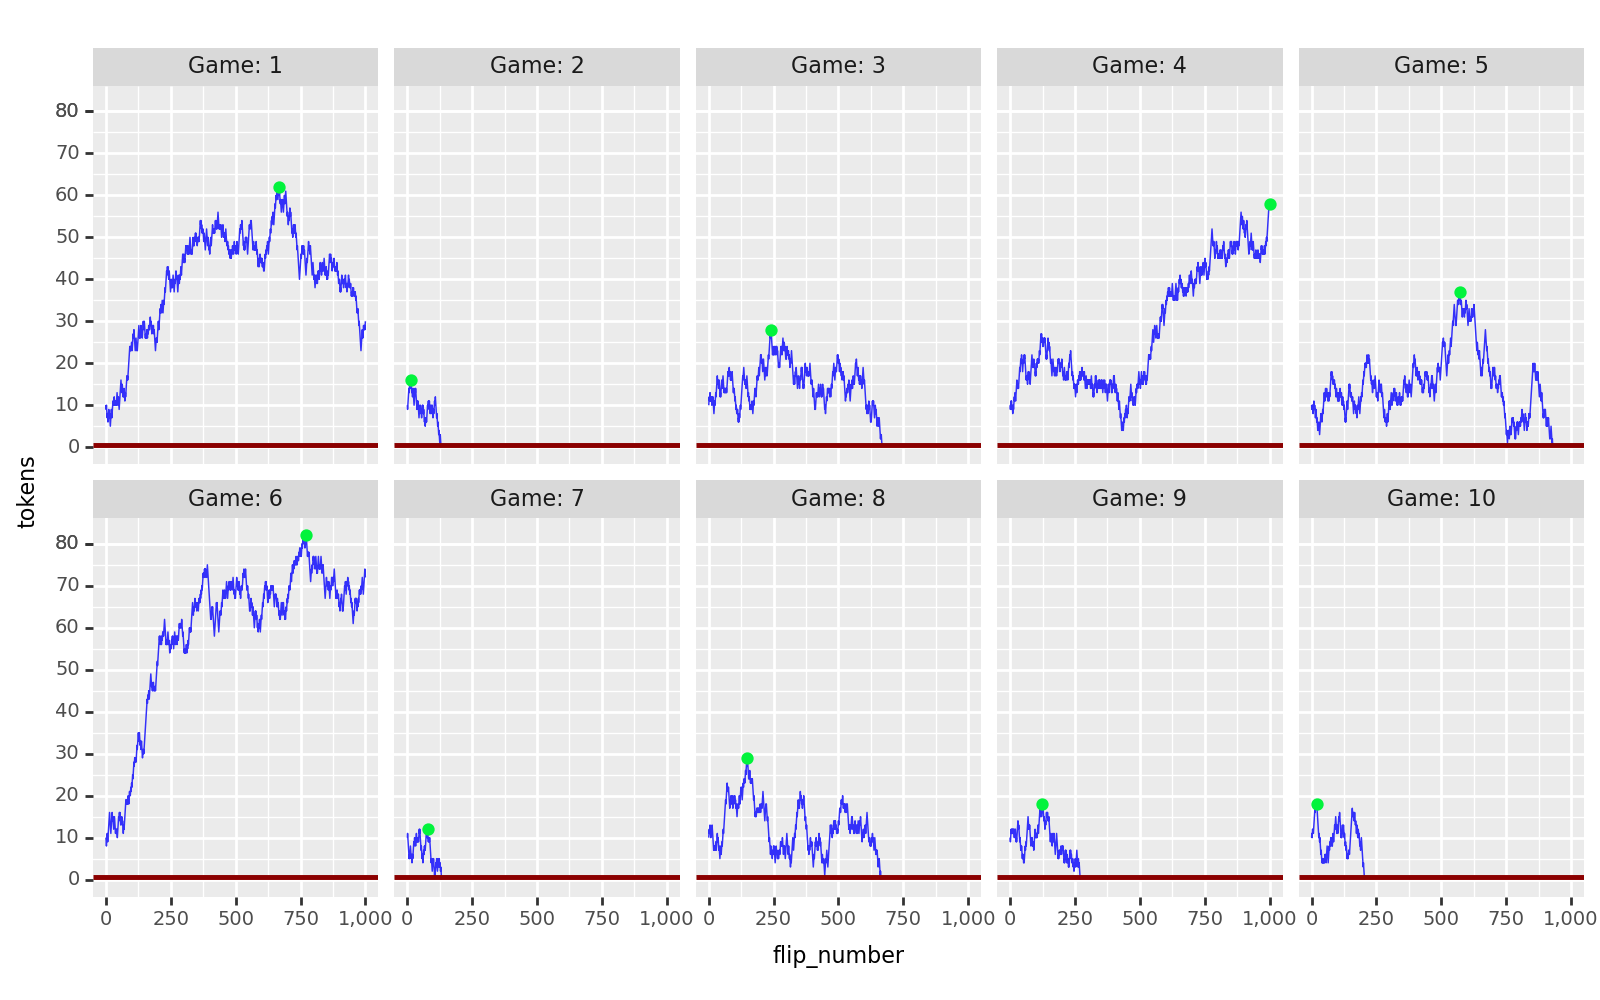

In [57]:
flips = list(enumerate(tokens_seq))
flips = pd.DataFrame(flips, columns = ['game', 'tokens'])
flips = flips.explode('tokens')
flips['game'] = flips['game'] + 1
flips['game_no'] = flips['game']
flips['game'] = flips['game'].astype('str')
flips['game'] = 'Game: ' + flips['game']
flips['flip_number'] = flips.groupby('game').cumcount()
flips['tokens'] = flips['tokens'].astype('int')

flips['max'] = flips.groupby('game')['tokens'].cummax()
flips.loc[flips['max'] != flips['tokens'], 'max'] = np.nan

max_flip = flips[~np.isnan(flips['max'])]
max_flip = max_flip.groupby('game').apply(lambda x: x.iloc[[-1]]).reset_index(drop = True)

flips.drop('max', axis = 1, inplace = True)
flips = flips.merge(max_flip[['game', 'flip_number', 'max']], how = 'outer')

########################################
n_flips = 10
temp = flips[flips['game_no'].isin(range(0, n_flips + 1))]

temp['game'] = pd.Categorical(temp['game'],
                              categories = ['Game: 1', 'Game: 2', 'Game: 3', 'Game: 4', 'Game: 5',
                                                          'Game: 6', 'Game: 7', 'Game: 8', 'Game: 9', 'Game: 10'],
                              ordered = True)
p = (ggplot(temp, aes(x = 'flip_number')) +
         geom_line(aes(y = 'tokens'), size = .3, color = "#3330f9") +
         geom_point(aes(y = 'max'), size = 1.5, color = "#02f33c") +
         geom_hline(yintercept = .5, size = 1, color = "darkred") +
         theme(legend_position = "none",
               axis_text_x = element_text(size = 7),
               plot_title = element_text(size = 8),
               axis_text_y = element_text(size = 7),
               axis_title = element_text(size = 8),
               legend_title = element_text(size = 6),
               legend_text = element_text(size = 4),
               strip_text = element_text(size = 8),
               figure_size = (8, 5)) +
          scale_x_continuous(labels = comma_format()) +
          scale_y_continuous(breaks = [0,10,20,30,40,50,60,70,80,80,100]) +
          facet_wrap('game', ncol = 5))

p.draw(show = False)

Notice a few things straight away.  

- Each "Game" begins with 10 tokens, and will either end when we lose all of our tokens by hiting 0, or by quiting when we hit the maximum number of 1,000 flips (whichever comes first)
- Some games we went straight down and never got higher than the 10 tokens we started with
- Some games we made at least a small profit throughout the game, but then eventually gave it all back and went bankrupt
- Some games we made it all the way to the end of the 1,000 flips while still having at least some tokens left

In [59]:
x = n - n_flips
md("Now remember, we played this game {} times, so there are actually another {} other games we can look at to see what happened.  We're jumping a head a bit, but there's some really foundational mathematics at play here called the _Law of Large Numbers_ which we'll cover later which allows us to ask some really cool questions given our history of playing this game.".format(n, x))

Now remember, we played this game 100 times, so there are actually another 90 other games we can look at to see what happened.  We're jumping a head a bit, but there's some really foundational mathematics at play here called the _Law of Large Numbers_ which we'll cover later which allows us to ask some really cool questions given our history of playing this game.

>_What's the probability of playing the game and never sitting on a profit?_ <br>
>_What's the probabiliy of surviving and playing the game all the way to the end of the 1,000 coin flips?_ <br>
>_What's the probability of running out of tokens before doubling our money and making a profit of 10 tokens?_ <br>
>_What's the ideal profit amount to walk away from the game at which gives us an 80% chance of winning?_

Next, see all of those little green dots in each game?  Those are highlighting the maximum number of tokens held at any point during each game.  Could we answer some of these questions if we collect all of those maximum value of tokens held during each game and create an _empirical cumulative density function_?  I think so!  

Let's give it a try.

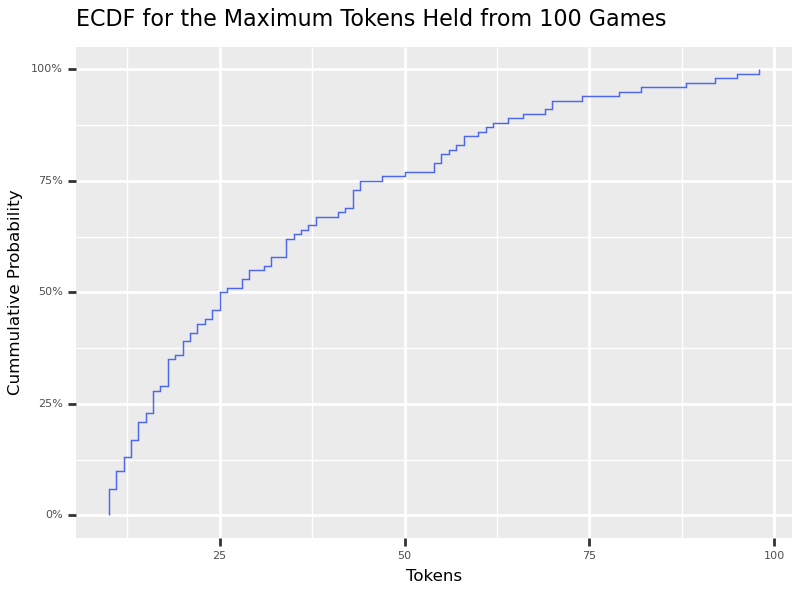

In [182]:
from statsmodels.distributions.empirical_distribution import ECDF

# Calculate the empirical cummulative density function & create a dataframe
ecdf = ECDF(max_tokens)
ecdf.x[0] = ecdf.x[1]
ecdf_dat = pd.DataFrame({'x': ecdf.x,
                         'y': ecdf.y})

# Plot CDF
p = (ggplot(ecdf_dat, aes(x = 'x', y = 'y')) +
         geom_step(color = "#4E68EC", size = .3) +
         labs(x = "Tokens", y = "Cummulative Probability") +
         ggtitle("ECDF for the Maximum Tokens Held from " + str(n) + " Games") +
         theme(axis_text_x = element_text(size = 4),
               plot_title = element_text(size = 8),
               axis_text_y = element_text(size = 4),
               axis_title = element_text(size = 6),
               legend_title = element_text(size = 6),
               legend_text = element_text(size = 4),
               strip_text = element_text(size = 6),
               figure_size = (4,3)) +
          scale_y_continuous(labels = percent_format()))

p.draw(show = False)

Beautiful!  Can you already see how it might work?  See the relationship between the cumulative probability percentage on the y-aix and number of tokens on the x-axis?  And notice the operative word _cumulative_?  That should tip you off that we will always start at 0% and end at 100%.  Because one of the core tenants of probability theory states that probabilities must add up to 100%, this means no matter where you are on the curve you'll be able to make a statement about the probability of a specific number of tokens less than _and_ greater than those values.  Pretty awesome!

What's really cool about this cumulative density function is that it's actually learning from our data, hence the term _empirical_.  So as long as we have a sufficient number of samples, we can begin to ask some questions about expected outcomes and feel pretty good about our confidence in those estimates.

In [189]:
# Retrieve the cumulative probability of the ecdf at the value of 10 tokens
md("Revisiting our first question from above, _What's the probability of playing the game and never sitting on a profit?_ Turns out there's a {}% chance of immediately losing money and never getting back to break even.".format(round(ecdf(10) * 100), 2))

Revisiting our first question from above, _What's the probability of playing the game and never sitting on a profit?_ Turns out there's a 6% chance of immediately losing money and never getting back to break even.

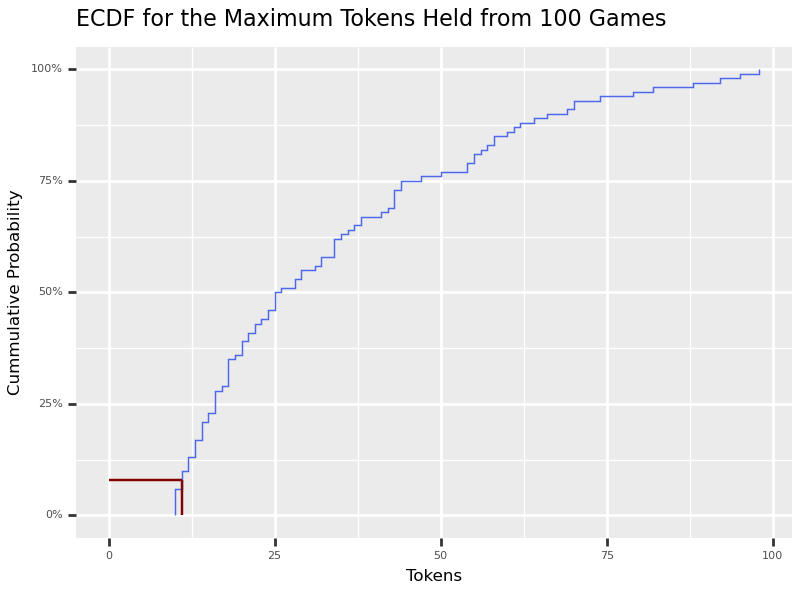

In [184]:
# Set container for the cumulative probability we want, and find the token value that corresponds to it
y_prob = .08
x_val = ecdf_dat.loc[ecdf_dat.y == y_prob, 'x']

# Plot CDF with 50% line indicators
p = (ggplot(ecdf_dat, aes(x = 'x', y = 'y')) +
         geom_step(color = "#4E68EC", size = .3) +
         geom_segment(aes(x = 0,
                          xend = x_val,
                          y = y_prob,
                          yend = y_prob),
                      color = 'maroon') +
         geom_segment(aes(x = x_val,
                          xend = x_val,
                          y = 0,
                          yend = y_prob),
                      color = 'maroon') +
         labs(x = "Tokens", y = "Cummulative Probability") +
         ggtitle("ECDF for the Maximum Tokens Held from " + str(n) + " Games") +
         theme(axis_text_x = element_text(size = 4),
               plot_title = element_text(size = 8),
               axis_text_y = element_text(size = 4),
               axis_title = element_text(size = 6),
               legend_title = element_text(size = 6),
               legend_text = element_text(size = 4),
               strip_text = element_text(size = 6),
               figure_size = (4,3)) +
          scale_y_continuous(labels = percent_format()))

p.draw(show = False)

In [66]:
md("Remember, that means there's a {}% chance of sitting on a profit of at least 1 token at some point during the game.".format(round((1 - ecdf(10)) * 100), 2))

Remember, that means there's a 94% chance of sitting on a profit of at least 1 token at some point during the game.

Does that sound like a game you want to play?  I'll let you decide that one for yourself...

How do we interpret the graph then?  It's actually pretty simple.  The cumulative probability shows where some percentage of the observations were less than that value on the x-axis, and the inverse percentage is how much of the time the observations were greater than that number.

Say you're actually pretty risk tolerant and you would like to know where you might want to start thinking about cashing out given a 50% chance of reaching that amount? 

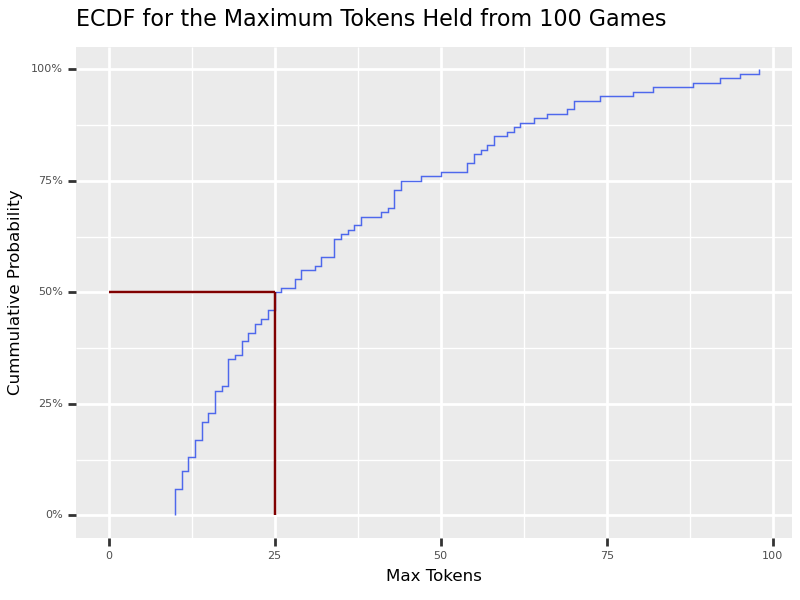

In [186]:
# Set container for the cumulative probability we want, and find the token value that corresponds to it
y_prob = .5
x_val = ecdf_dat.loc[ecdf_dat.y == y_prob, 'x']

# Plot CDF with 50% line indicators
p = (ggplot(ecdf_dat, aes(x = 'x', y = 'y')) +
         geom_step(color = "#4E68EC", size = .3) +
         geom_segment(aes(x = 0,
                          xend = x_val,
                          y = y_prob,
                          yend = y_prob),
                      color = 'maroon') +
         geom_segment(aes(x = x_val,
                          xend = x_val,
                          y = 0,
                          yend = y_prob),
                      color = 'maroon') +
         labs(x = "Max Tokens", y = "Cummulative Probability") +
         ggtitle("ECDF for the Maximum Tokens Held from " + str(n) + " Games") +
         theme(axis_text_x = element_text(size = 4),
               plot_title = element_text(size = 8),
               axis_text_y = element_text(size = 4),
               axis_title = element_text(size = 6),
               legend_title = element_text(size = 6),
               legend_text = element_text(size = 4),
               strip_text = element_text(size = 6),
               figure_size = (4,3)) +
          scale_y_continuous(labels = percent_format()))

p.draw(show = False)

In [70]:
from IPython.display import Markdown as md
x = round(list(ecdf_dat.loc[ecdf_dat.y == .5, 'x'].values)[0])
md("Above we can see above that 50% of the time you would fail to reach {} tokens, and 50% of the time you could expect to exceed it.  Definitely a game of chance, and not one of skill.".format(x))

Above we can see above that 50% of the time you would fail to reach 25 tokens, and 50% of the time you could expect to exceed it.  Definitely a game of chance, and not one of skill.

Which makes sense if you think about it, because we started with 10 tokens and we're flipping a fair coin, so we should have approximately the same chance of losing 10 tokens as we do gaining 10!

**<h3>Categorical Plots</h3>**

Finally, our last grouping of plot types:  Categorical Plots.  

These are exactly as they sound, plots for visualizing categorical data in some way.  Some of these will look very familiar to what we've seen already, while others may be a little new.  What they'll all have in common though is categorical aggregation or faceting in some way that allows us to segment by these non numeric groups.

I see no reason to break from using the tips data at this point, so we'll carry on as we have been.

In [158]:
dat = sns.load_dataset("tips") 
dat.reset_index(drop = True, inplace = True)
dat['tip_pct'] = dat.tip / dat.total_bill

dat.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059447
1,10.34,1.66,Male,No,Sun,Dinner,3,0.160542
2,21.01,3.50,Male,No,Sun,Dinner,3,0.166587
3,23.68,3.31,Male,No,Sun,Dinner,2,0.139780
4,24.59,3.61,Female,No,Sun,Dinner,4,0.146808
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,0.203927
240,27.18,2.00,Female,Yes,Sat,Dinner,2,0.073584
241,22.67,2.00,Male,Yes,Sat,Dinner,2,0.088222
242,17.82,1.75,Male,No,Sat,Dinner,2,0.098204


__<h5>Bar Plots</h5>__

Bar plots look very similar to histograms, the difference being here we're not spreading the frequencies of a numeric variable out by its range of values across the x-axis, but rather showing the categorical levels of a feature on the x-axis and the counts on the y-axis.

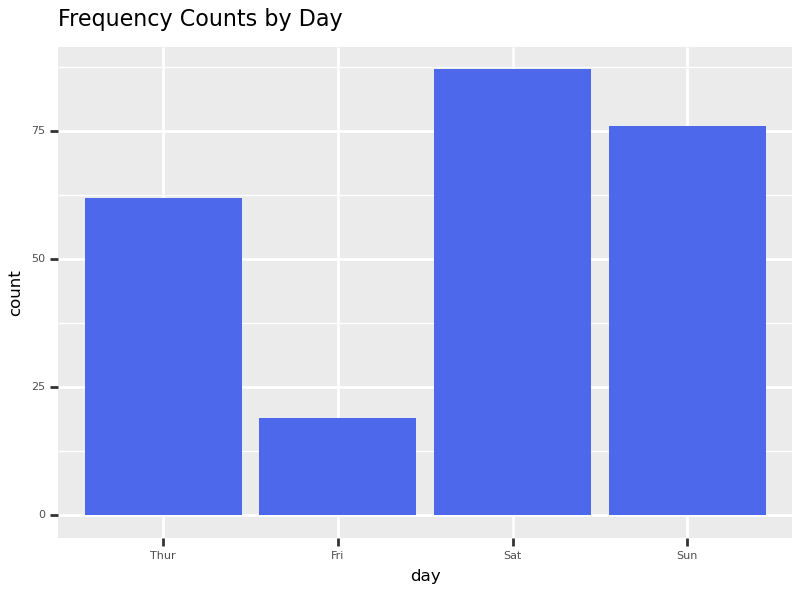

In [77]:
# Counts of categorical levels contained in the "day" feature
p = (ggplot(dat, aes(x = 'day')) +
         geom_bar(fill = "#4E68EC") +
         ggtitle("Frequency Counts by Day") +
         theme(axis_text_x = element_text(size = 4),
               plot_title = element_text(size = 8),
               axis_text_y = element_text(size = 4),
               axis_title = element_text(size = 6),
               legend_title = element_text(size = 6),
               legend_text = element_text(size = 4),
               strip_text = element_text(size = 6),
               figure_size = (4,3)) +
          scale_y_continuous(labels = comma_format()))

p.draw(show = False)

Of course we can also use the aggregation funtionality within the barplot to show numeric values _by_ these same levels contained within a categorical feature.

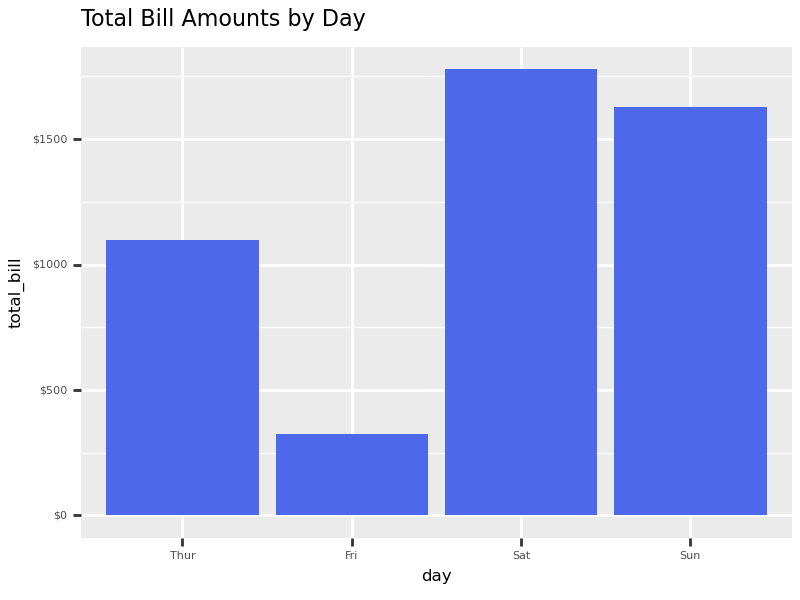

In [160]:
# Total summed values for "total_bill" by "day"
p = (ggplot(dat, aes(x = 'day', y = 'total_bill')) +
         geom_bar(stat = 'identity', fill = "#4E68EC") +
         ggtitle("Total Bill Amounts by Day") +
         theme(axis_text_x = element_text(size = 4),
               plot_title = element_text(size = 8),
               axis_text_y = element_text(size = 4),
               axis_title = element_text(size = 6),
               legend_title = element_text(size = 6),
               legend_text = element_text(size = 4),
               strip_text = element_text(size = 6),
               figure_size = (4,3)) +
          scale_y_continuous(labels = currency_format("$", digits = 0)))

p.draw(show = False)

<h4>Boxplots</h4>

Boxplots are again similar to some others we've seen, namely bar plots and density plots.  We're essentially using a bar plot layout to view the statistical distribution of the values contained within a feature.  Recall the numeric quantile summaries we've been working with?  Well, these are graphical representations of these summaries laid out in a bar with additional quartile information overlaid on top.

How might this work?

Curious if there's a statistical difference in tipping by day of the week?  We can use boxplots to nicely visualize the differences!  However, before we do, let's print out the numeric summaries for reference.

In [82]:
# Print summary statistics for tips by day 
dat.groupby('day')['tip'].describe()

,count,mean,std,min,25%,50%,75%,max
day,,,,,,,,
Thur,62.0,2.771452,1.240223,1.25,2.0000,2.305,3.3625,6.70
Fri,19.0,2.734737,1.019577,1.00,1.9600,3.000,3.3650,4.73
Sat,87.0,2.993103,1.631014,1.00,2.0000,2.750,3.3700,10.00
Sun,76.0,3.255132,1.234880,1.01,2.0375,3.150,4.0000,6.50


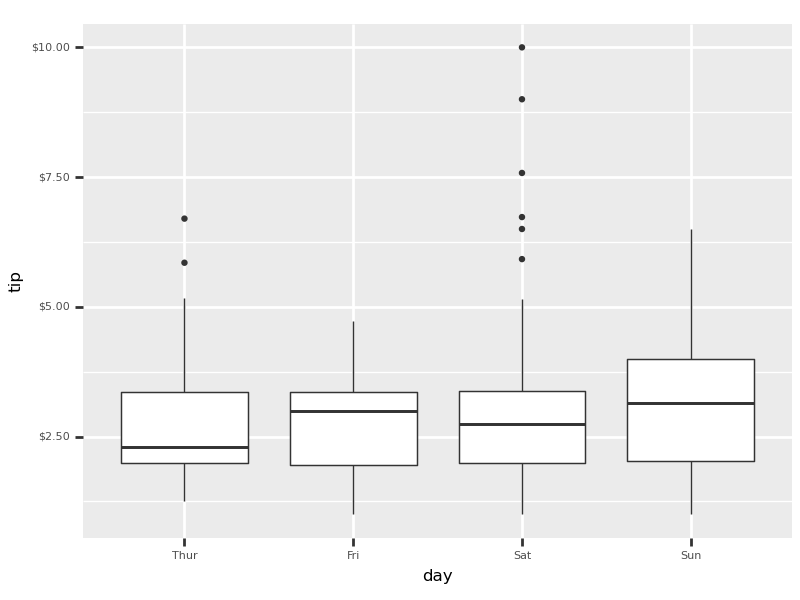

In [168]:
# Boxplot for tips by day
p = (ggplot(dat, aes(x = 'day', y = 'tip')) +
         geom_boxplot(size = .3, outlier_size = 0.3) +
         theme(axis_text_x = element_text(size = 4),
               plot_title = element_text(size = 8),
               axis_text_y = element_text(size = 4),
               axis_title = element_text(size = 6),
               legend_title = element_text(size = 6),
               legend_text = element_text(size = 4),
               strip_text = element_text(size = 6),
               figure_size = (4,3)) +
          scale_y_continuous(labels = currency_format("$", digits = 2)))

p.draw(show = False)

Nice.  The minimums and maximums are easily identifiable.  Now, remember the discussion about inner quartile range (25th-75th percentiles)?  Well those are observable in the plot as the outer horizontal lines of the boxes.  The thickest line in the middle of the box is the median value.  And see those vertical lines sticking out above and below each box?  Those are the 1.5x the IQR range we've also been discussing as an indication of the upper and lower limits for outliers.  Which leaves the dots beyond those outlier limits.  Can you guess what those are?  Outliers!  Good guess.

We could also do some coloring and additional grouping and faceting if we'd like to get a little more information in one graphic, just don't forget that _simple is always better_, as things can get overly complicated super quickly.

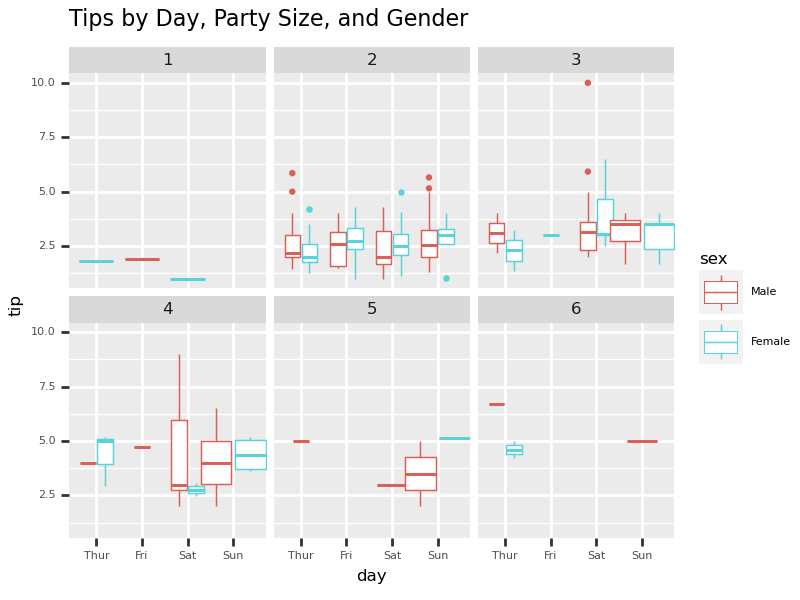

In [170]:
# Plot boxplot with size facet and color aesthetic by gender
p = (ggplot(dat, aes(x = 'day', y = 'tip', color = 'sex')) +
         geom_boxplot(size = .3, outlier_size = 0.3) +
         ggtitle("Tips by Day, Party Size, and Gender") +
         facet_wrap('size') +
         theme(axis_text_x = element_text(size = 4),
               plot_title = element_text(size = 8),
               axis_text_y = element_text(size = 4),
               axis_title = element_text(size = 6),
               legend_title = element_text(size = 6),
               legend_text = element_text(size = 4),
               strip_text = element_text(size = 6),
               figure_size = (4,3)) +
          scale_y_continuous(labels = comma_format(digits = 1)))

p.draw(show = False)

<h4>Violin Plots</h4>

Next up is one of my favorite types of plots, but also unfortunately one of the least used by others.  Sad, because it's really an informative one.

Let's start with throwing boxplots under the bus first.  Did you happen to notice a potential issue with boxplots?  It's ok if you didn't catch it.  Yes, these plots show a graphical representation of the numeric distribution of a variable, but they can easily obsfucate the real underlying spread.  Let's show an example to make this clear.  

First, we'll simulate a bimodal distribution and see what it looks like in a histogram and density curve.

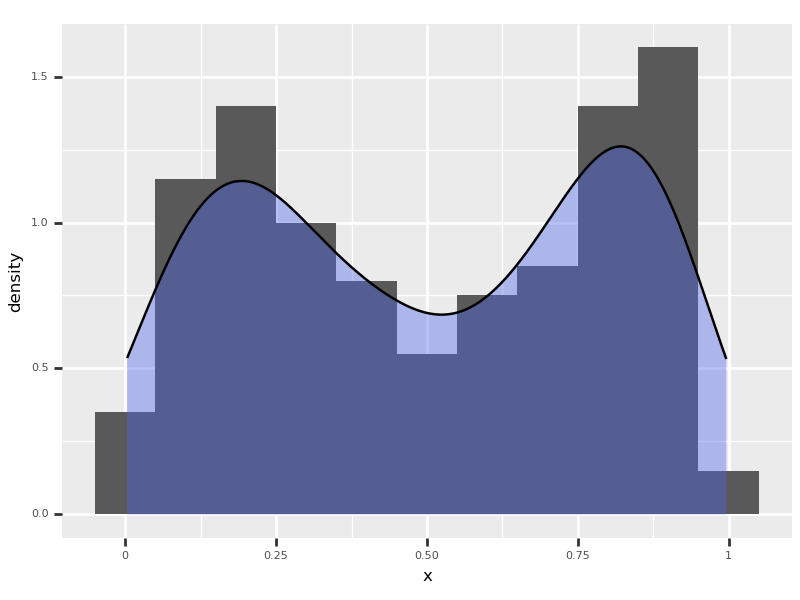

In [88]:
# Create a bimodal distribution
x1 = np.random.beta(5, 1.5, n)
x2 = np.random.beta(1.5, 5, n)
X = pd.DataFrame({ 'x' : np.concatenate([x1, x2]) }) 

# Plot density curve over histogram
p = (ggplot(X, aes(x = 'x', y = after_stat("density"))) +
         geom_histogram(binwidth = .1) +
         geom_density(fill = "#4E68EC", alpha = .4) +
         scale_fill_discrete(guide = False) +
         theme(axis_text_x = element_text(size = 4),
               plot_title = element_text(size = 8),
               axis_text_y = element_text(size = 4),
               axis_title = element_text(size = 6),
               legend_title = element_text(size = 6),
               legend_text = element_text(size = 4),
               strip_text = element_text(size = 6),
               figure_size = (4,3)) +
          scale_y_continuous(labels = comma_format(digits = 1)))

p.draw(show = False)

Now, using the same data, first we print the numeric summary statistics, and then graphs for a boxplot and violin plot side by side so we can compare and contrast.

In [90]:
# Print summary statistics
X[['x']].describe().T

,count,mean,std,min,25%,50%,75%,max
x,200.0,0.504638,0.302584,0.003068,0.218618,0.497121,0.797132,0.9961


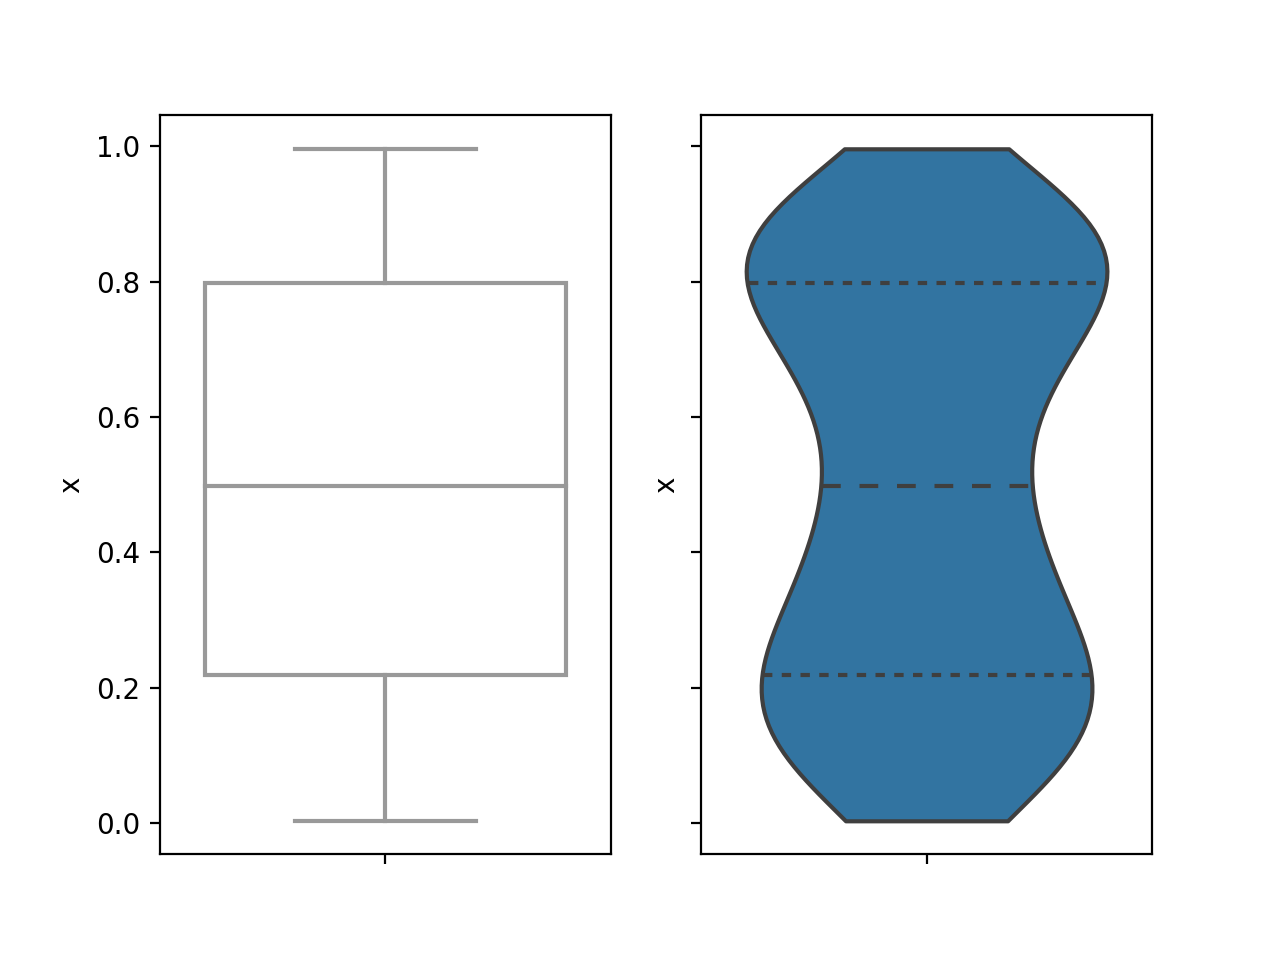

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Plot a boxplot and violin plot sharing the same y-axis
fig, axs = plt.subplots(ncols = 2, sharey = True)
sns.boxplot(y = 'x', data = X, ax = axs[0], color = 'white')
sns.violinplot(y = 'x', split = True, inner = "quart", cut = 0, data = X, ax = axs[1]);

Very very interesting.  Hopefully you can see what might be the issue with the boxplot now.  Would you really have been able to understand the distribution of data from the boxplot by itself?  The new violin plot clearly shows the underlying distribution much better than the boxplot does.  It's essentially a density plot turned on it's side with the quartiles overlaid.  Super informative.  

This example is just a simple caution.  While boxplots are awesome and super helpful, they can also easily hide distributional information if the data is non-normal.  This isn't to say violin plots are infallable though.  Simply understand every plot type has its strengths and weaknesses, and try not to fall in love with just one type and you'll be fine.

Back to violin plots.  We can do some very cool things with these by splitting, coloring, and faceting.  Here's just a taste below if you wanted to see the difference in tipping percentage by gender, and whether or not they were in a party with a smoker.  It would be nearly impossible to see this same amount of information in such a succient way in a boxplot.

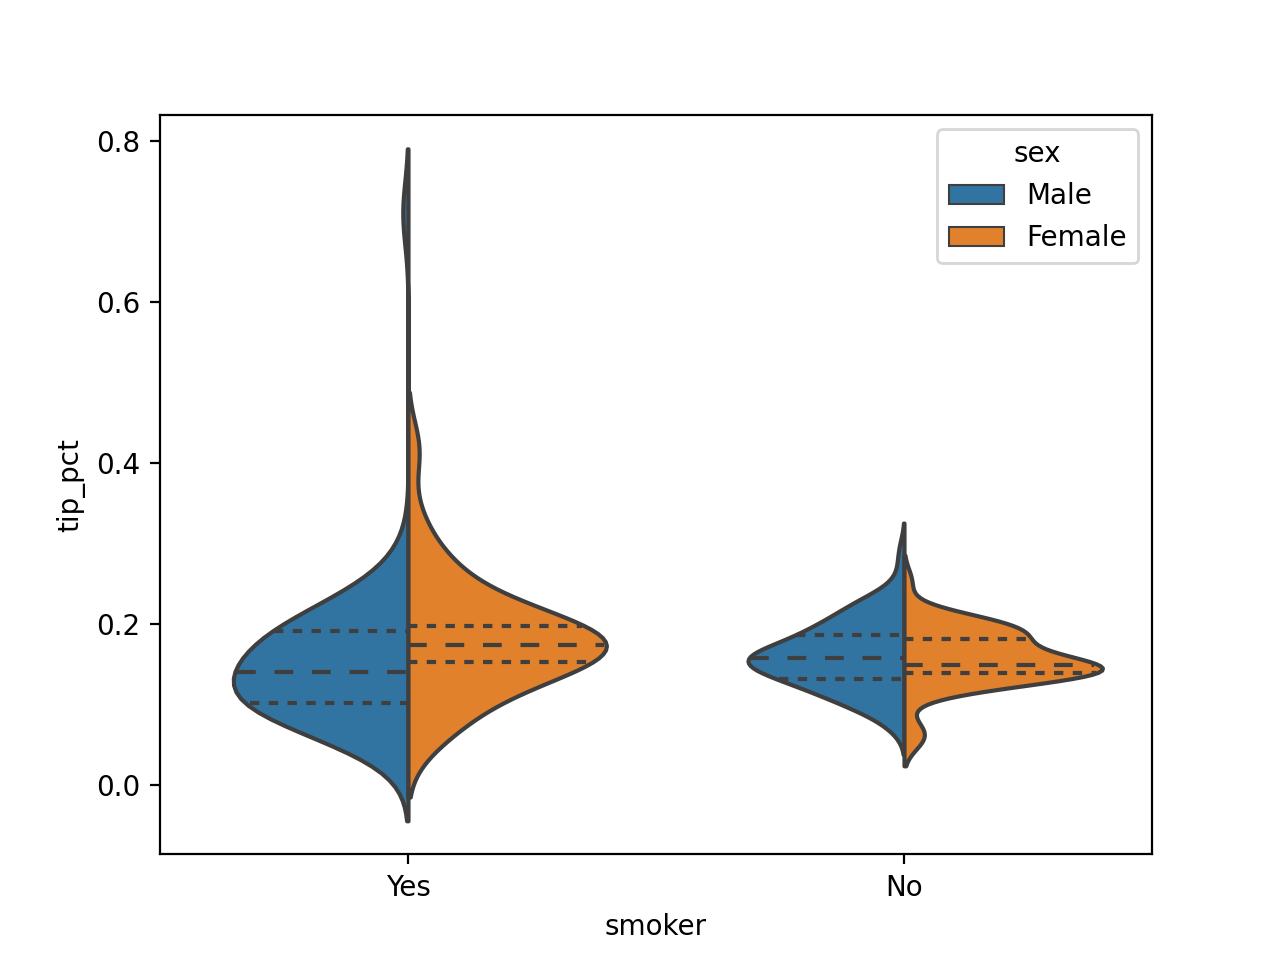

In [143]:
# Plot split violin plot
sns.violinplot(data = dat, x = "smoker", y = "tip_pct", hue = "sex", inner = "quart", split = True);

<h3>Mosaic Plots</h3>

And now our final plot type we're going to show: Mosiac Plots.

Mosaic plots are definitely not the most common plot you'll see, but it's good to know there's a simple way to plot multiple categorical variables against each other.  Under the hood, mosiac plots are leveraging what's known as _crosstabs_, which caluclate the overlapping percentages amongst the categorical groups.

Let's see how it works using the sex and day variables in the tips data.  First, we show a crosstab table to illustrate the actual numbers behind the graph.

In [97]:
# Print the crosstab table for sex and day
pd.crosstab(dat['sex'], dat['day'])

day,Thur,Fri,Sat,Sun
sex,,,,
Male,30,10,59,58
Female,32,9,28,18


And now the mosaic plot, which is just a graphical representation of the crosstable counts above.

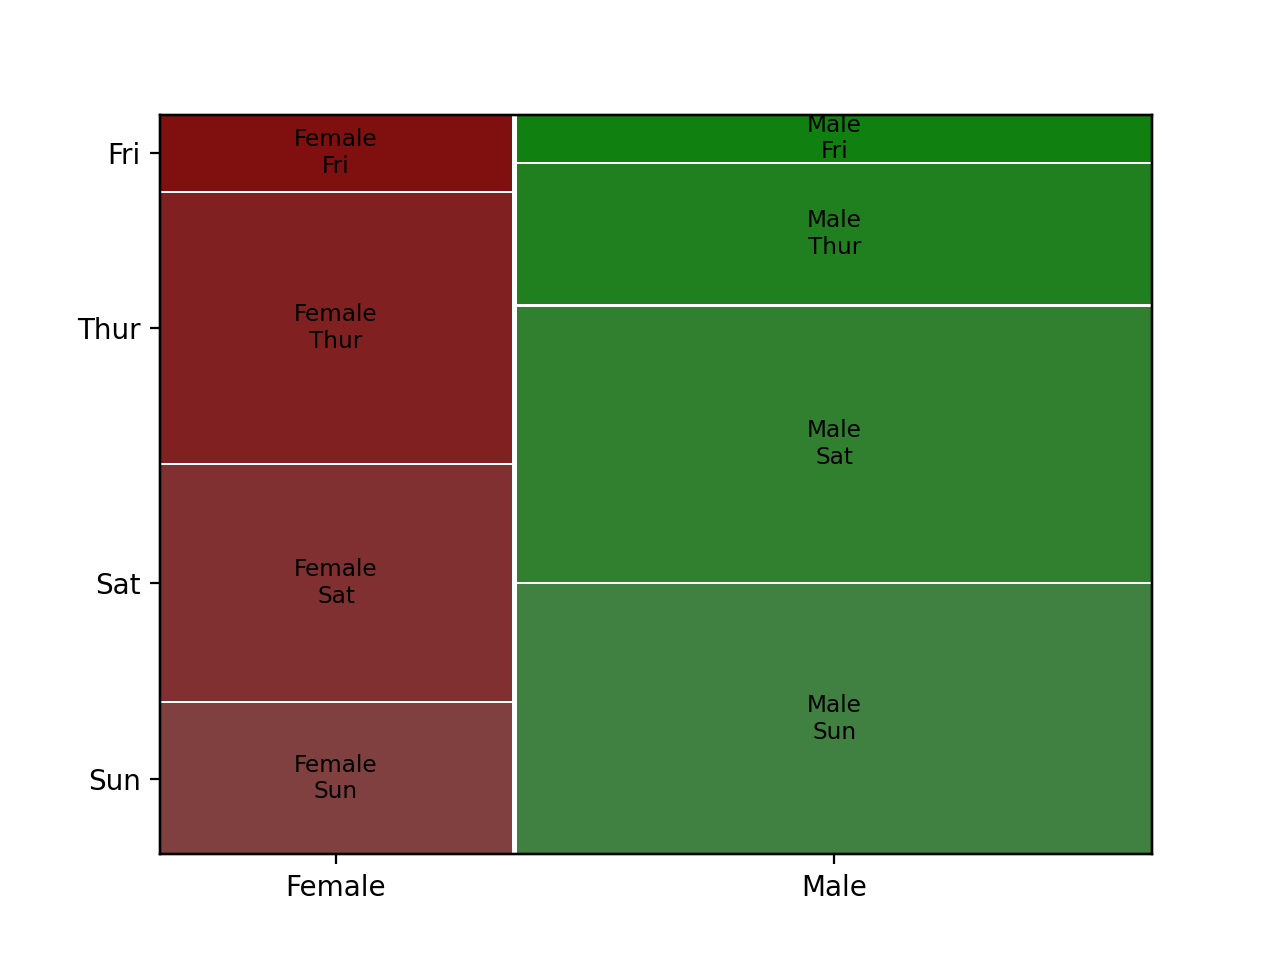

In [99]:
from statsmodels.graphics.mosaicplot import mosaic

# Plot 2 feature mosaic plot
mosaic(dat, ['sex', 'day'])
plt.show()

**<h3>What Did We Learn?</h3>**

Another long one, I know.  But there's so many different ways to visualize your data and we wanted to try to expose you to as many useful ways as possible.  You'll start to get comfortable over time, and with practice you'll be able to quickly associate the different plot types with the specifics of your data at hand.  Google and your application documentations will come to your rescue when needed.

The last thought to leave you with is that you'll quickly come to realize there are many dimensions you can force into a graph, but just because we can doesn't mean we should.  Graphs should not be complicated or confusing.  The point you're trying to make should jump out of the image at the viewer, and rarely should require any outside explanation.

Remember, _simple is always better_.

Happy plotting.